
--- Departman Bazlı Özet ---


,Total_Employees,Total_Attrition,Avg_MonthlyIncome,Total_Annual_Cost,Cost_Percentage,Attrition_Rate
Department,,,,,,
Human Resources,63,12,6654.507937,5030808.0,4.38561,19.047619
Research & Development,961,133,6281.252862,72435408.0,63.14561,13.839750
Sales,446,92,6959.172646,37245492.0,32.46878,20.627803


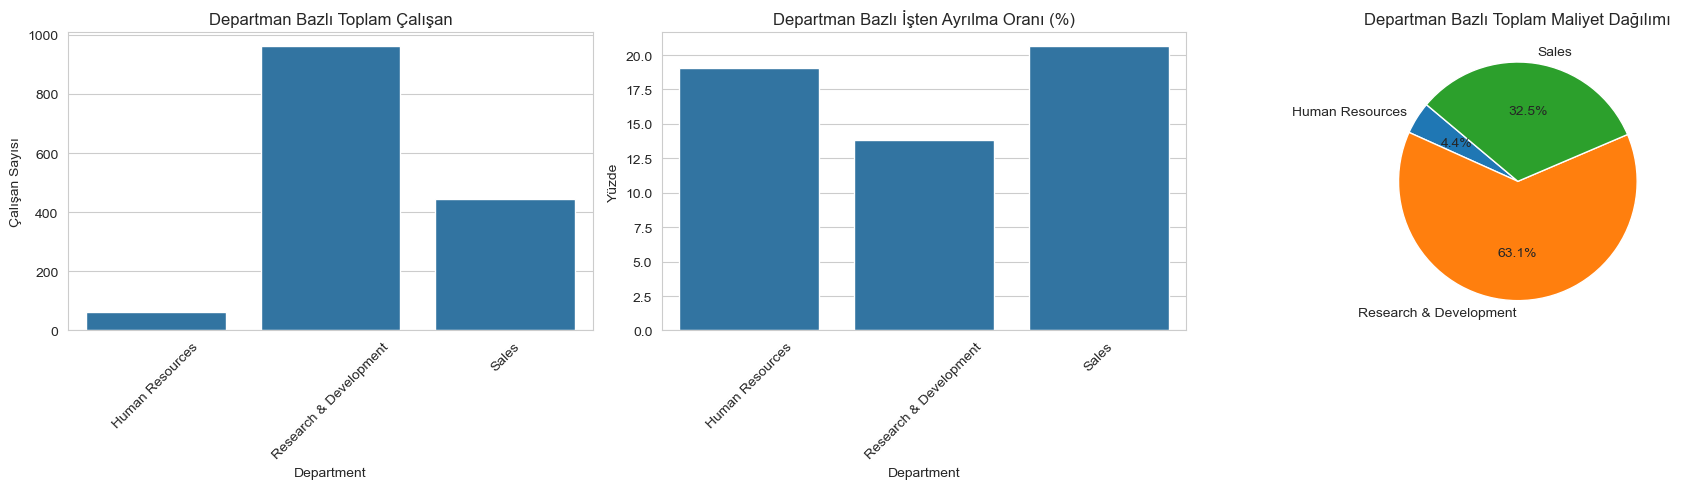


Departman Bazında Çalışan Sayısı:
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: EmployeeNumber, dtype: int64

Departman Bazında Cinsiyet Dağılımı:
Gender                  Female  Male
Department                          
Human Resources             20    43
Research & Development     379   582
Sales                      189   257


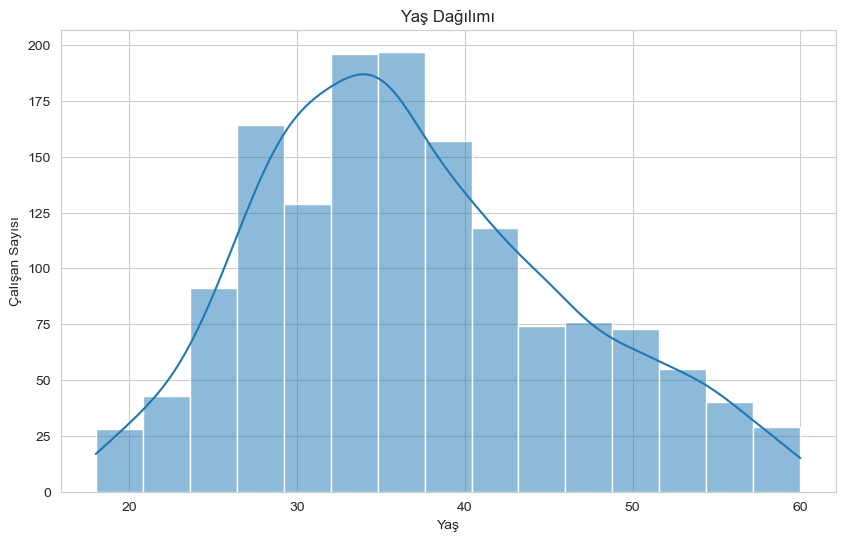

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Veri Yükleme
df_hr = pd.read_excel(
    r"C:\Users\DeLL\Downloads\Otel_Operasyon_Master.xlsx",
    sheet_name="2_IK_Personel"
)

# Departman bazlı özet
departman_summary = df_hr.groupby("Department").agg(
    Total_Employees=("EmployeeNumber", "count"),
    Total_Attrition=("Attrition", lambda x: (x == "Yes").sum()),
    Avg_MonthlyIncome=("MonthlyIncome", "mean")
)

departman_summary["Total_Annual_Cost"] = departman_summary["Avg_MonthlyIncome"] * 12 * departman_summary["Total_Employees"]
departman_summary["Cost_Percentage"] = 100 * departman_summary["Total_Annual_Cost"] / departman_summary["Total_Annual_Cost"].sum()
departman_summary["Attrition_Rate"] = 100 * departman_summary["Total_Attrition"] / departman_summary["Total_Employees"]

print("\n--- Departman Bazlı Özet ---")
display(departman_summary)

# Görselleştirme
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# 1. Çalışan sayısı
sns.barplot(x=departman_summary.index, y="Total_Employees", data=departman_summary, ax=axes[0])
axes[0].set_title("Departman Bazlı Toplam Çalışan")
axes[0].set_ylabel("Çalışan Sayısı")
axes[0].tick_params(axis='x', rotation=45)  # <- Uyarısız x-tick

# 2. İşten ayrılma oranı
sns.barplot(x=departman_summary.index, y="Attrition_Rate", data=departman_summary, ax=axes[1])
axes[1].set_title("Departman Bazlı İşten Ayrılma Oranı (%)")
axes[1].set_ylabel("Yüzde")
axes[1].tick_params(axis='x', rotation=45)  # <- Uyarısız x-tick

# 3. Maliyet yüzdesi
axes[2].pie(departman_summary["Cost_Percentage"], labels=departman_summary.index, autopct='%1.1f%%', startangle=140)
axes[2].set_title("Departman Bazlı Toplam Maliyet Dağılımı")

plt.tight_layout()
plt.show()

# Departman bazında toplam çalışan sayısı
departman_count = df_hr.groupby("Department")["EmployeeNumber"].nunique().sort_values(ascending=False)
print("\nDepartman Bazında Çalışan Sayısı:")
print(departman_count)

# Departman bazında cinsiyet dağılımı
gender_count = df_hr.groupby(["Department", "Gender"])["EmployeeNumber"].count().unstack()
print("\nDepartman Bazında Cinsiyet Dağılımı:")
print(gender_count)

# Yaş dağılımı histogramı
plt.figure(figsize=(10,6))
sns.histplot(df_hr["Age"], bins=15, kde=True)
plt.title("Yaş Dağılımı")
plt.xlabel("Yaş")
plt.ylabel("Çalışan Sayısı")
plt.show()